In [1]:
import logging
from pathlib import Path

import cartopy
import matplotlib.pyplot as plt
import xarray
import yaml
from metplotpy.contributed.fv3_physics_tend import (
    cross_section_vert,
    physics_tend,
    planview_fv3,
    vert_profile_fv3,
)
from metpy.units import units

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s", force=True
)  # Change the level as needed

In [3]:
METPLOTPY_BASE = Path("/glade/derecho/scratch/ahijevyc/METplotpy")
PHYSICS_TEND_DIR = METPLOTPY_BASE / "metplotpy/contributed/fv3_physics_tend"
TEST_FILE_DIR = Path("/glade/campaign/mmm/parc/ahijevyc/METplotpy")

In [4]:
from dask.distributed import Client

client = Client()
client.dashboard_link

2025-03-05 16:11:56,016 - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2025-03-05 16:11:56,122 - INFO - State start
2025-03-05 16:11:56,207 - INFO - Found stale lock file and directory '/glade/derecho/scratch/ahijevyc/tmp/dask-scratch-space/scheduler-chygrro2', purging
2025-03-05 16:11:56,216 - INFO - Found stale lock file and directory '/glade/derecho/scratch/ahijevyc/tmp/dask-scratch-space/scheduler-e2fqxeyn', purging
2025-03-05 16:11:56,259 - INFO -   Scheduler at:     tcp://127.0.0.1:41641
2025-03-05 16:11:56,261 - INFO -   dashboard at:  https://jupyterhub.hpc.ucar.edu/stable/user/ahijevyc/proxy/8787/status
2025-03-05 16:11:56,262 - INFO - Registering Worker plugin shuffle
2025-03-05 16:11:56,296 - INFO -         Start Nanny at: 'tcp://127.0.0.1:33987'
2025-03-05 16:12:00,571 - INFO - Register worker addr: tcp://127.0.0.1:46021 name: 0
2025-03-05 16:12:00,574 - INFO - Starting worker compute strea

'https://jupyterhub.hpc.ucar.edu/stable/user/ahijevyc/proxy/8787/status'

In [5]:
# Oldest https://dtcenter.ucar.edu/dfiles/code/METplus/METplotpy/fv3_physics_tendency/
config = yaml.load(
    open(
        METPLOTPY_BASE / "test/fv3_physics_tend/fv3_physics_tend_defaults.yaml",
        encoding="utf8",
    ),
    Loader=yaml.FullLoader,
)
historyfile = TEST_FILE_DIR / "fv3_history.nc"
gridfile = TEST_FILE_DIR / "grid_spec.nc"
ds = physics_tend.prepare_ds(config, historyfile, gridfile)
ds

<xarray.Dataset> Size: 496MB
Dimensions:        (time: 2, pfull: 64, grid_yt: 117, grid_xt: 202)
Coordinates:
  * grid_xt        (grid_xt) float32 808B 1.0 2.0 3.0 4.0 ... 200.0 201.0 202.0
  * grid_yt        (grid_yt) float32 468B 1.0 2.0 3.0 4.0 ... 115.0 116.0 117.0
  * pfull          (pfull) float32 256B 0.3792 0.9639 1.765 ... 991.6 997.3
  * time           (time) datetime64[ns] 16B 2019-05-04T13:00:00 2019-05-04T1...
    lont           (grid_yt, grid_xt) float32 95kB ...
    latt           (grid_yt, grid_xt) float32 95kB ...
Data variables: (12/44)
    dq3dt_deepcnv  (time, pfull, grid_yt, grid_xt) float32 12MB ...
    dq3dt_mp       (time, pfull, grid_yt, grid_xt) float32 12MB ...
    dq3dt_nophys   (time, pfull, grid_yt, grid_xt) float32 12MB ...
    dq3dt_pbl      (time, pfull, grid_yt, grid_xt) float32 12MB ...
    dq3dt_phys     (time, pfull, grid_yt, grid_xt) float32 12MB ...
    dq3dt_shalcnv  (time, pfull, grid_yt, grid_xt) float32 12MB ...
    ...             ...
    tmp_i          (pfull, grid_yt, grid_xt) float32 6MB ...
    ugrd           (time, pfull, grid_yt, grid_xt) float32 12MB ...
    ugrd_i         (pfull, grid_yt, grid_xt) float32 6MB ...
    vgrd           (time, pfull, grid_yt, grid_xt) float32 12MB ...
    vgrd_i         (pfull, grid_yt, grid_xt) float32 6MB ...
    area           (grid_yt, grid_xt) float32 95kB ...
Attributes:
    filename:   fv3_history.nc
    title:      20190504.12Z.C403.32bit.non-hydro.regional
    grid_type:  regular
    grid_tile:  N/A
    history:    Mon Aug 22 13:00:21 2022: ncks -x -v phalf,refl_10cm,hgtsfc,p...
    NCO:        netCDF Operators version 5.0.3 (Homepage = http://nco.sf.net,...

2025-03-05 16:12:05,634 - INFO - <xarray.Dataset> Size: 44B
Dimensions:        ()
Data variables:
    dt3dt_lw       float32 4B <Quantity(0.0003693504258990288, 'kelvin / seco...
    dt3dt_sw       float32 4B <Quantity(0.0003744283167179674, 'kelvin / seco...
    dt3dt_pbl      float32 4B <Quantity(0.00303665897808969, 'kelvin / second')>
    dt3dt_deepcnv  float32 4B <Quantity(0.0036077741533517838, 'kelvin / seco...
    dt3dt_shalcnv  float32 4B <Quantity(0.0003442416782490909, 'kelvin / seco...
    dt3dt_mp       float32 4B <Quantity(0.0018687916453927755, 'kelvin / seco...
    dt3dt_orogwd   float32 4B <Quantity(0.00013212345947977155, 'kelvin / sec...
    dt3dt_rdamp    float32 4B <Quantity(0.0, 'kelvin / second')>
    dt3dt_congwd   float32 4B <Quantity(5.331854481482878e-06, 'kelvin / seco...
    dt3dt_phys     float32 4B <Quantity(0.0034924144856631756, 'kelvin / seco...
    dt3dt_nophys   float32 4B <Quantity(0.003152652410790324, 'kelvin / secon...
2025-03-05 16:12:05,636 - W

['temperature tendency due to long wave radiation', 'temperature tendency due to short wave radiation', 'temperature tendency due to PBL', 'temperature tendency due to deep convection', 'temperature tendency due to shallow convection', 'temperature tendency due to microphysics', 'temperature tendency due to orographic gravity wave drag', 'temperature tendency due to Rayleigh damping', 'temperature tendency due to convective gravity wave drag', 'temperature tendency due to physics', 'temperature tendency due to non-physics processes']


2025-03-05 16:12:06,232 - INFO - from 2019-05-04 13:00:00 to 2019-05-04 14:00:00
2025-03-05 16:12:06,387 - INFO - subtract 'phys' tendency variable from all_tendencies to avoid double-counting
2025-03-05 16:12:06,400 - INFO - subtract actual tendency from all_tendencies to get residual


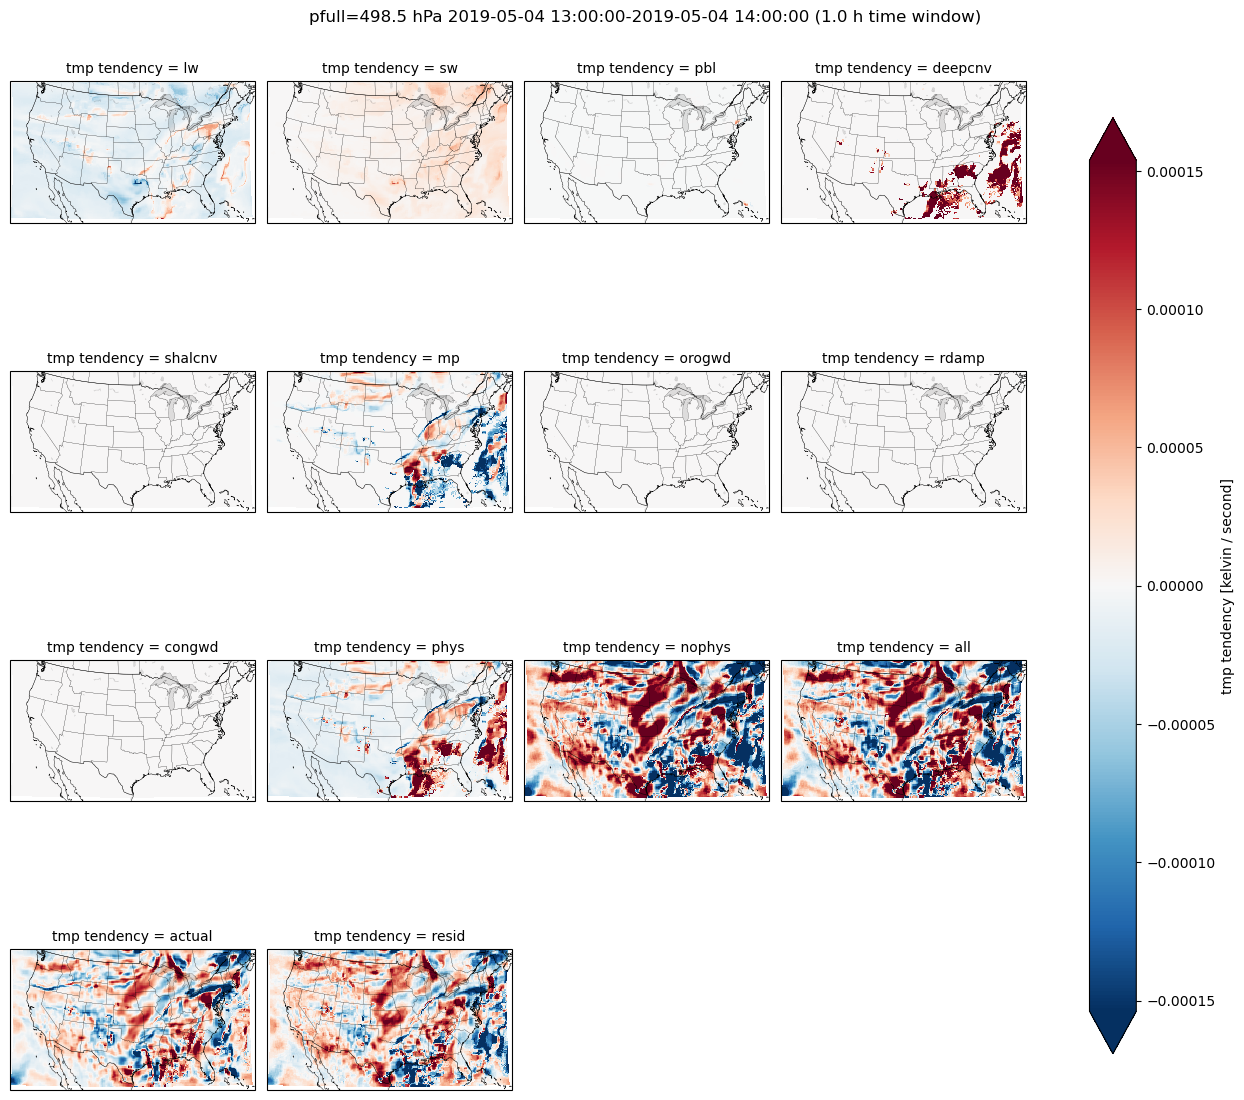

In [6]:
pcm = planview_fv3.planview(
    config,
    ds,
    pfull=[500],
    robust=True,
    shp=None,
    twindow=1,
    validtime="20190504T14",
)

In [7]:
# More recent history file (residual is zero)
config = yaml.load(
    open(PHYSICS_TEND_DIR / "use_case.yaml", encoding="utf8"),
    Loader=yaml.FullLoader,
)
historyfile = TEST_FILE_DIR / "model_applications/miscellaneous/fv3_physics_tendency/fv3_history.nc"
gridfile = TEST_FILE_DIR / "model_applications/miscellaneous/fv3_physics_tendency/grid_spec.nc"
ds = physics_tend.prepare_ds(config, historyfile, gridfile)
ds

2025-03-05 16:12:11,126 - INFO - round times to nearest millisec. before: ['2019-06-15T18:03:00.000003000']
2025-03-05 16:12:11,128 - INFO - after: ['2019-06-15T18:03:00.000000000']


<xarray.Dataset> Size: 116MB
Dimensions:             (time: 7, pfull: 64, grid_yt: 58, grid_xt: 101)
Coordinates:
  * grid_xt             (grid_xt) float32 404B 1.0 3.0 5.0 ... 197.0 199.0 201.0
  * grid_yt             (grid_yt) float32 232B 1.0 3.0 5.0 ... 111.0 113.0 115.0
  * pfull               (pfull) float32 256B 0.3792 0.9639 1.765 ... 991.6 997.3
  * time                (time) datetime64[ns] 56B 2019-06-15T18:03:00 ... 201...
    lont                (grid_yt, grid_xt) float32 23kB ...
    latt                (grid_yt, grid_xt) float32 23kB ...
Data variables:
    dtend_temp_cnvgwd   (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_deepcnv  (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_lw       (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_mp       (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_nophys   (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_orogwd   (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_pbl      (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_phys     (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_shalcnv  (time, pfull, grid_yt, grid_xt) float32 10MB ...
    dtend_temp_sw       (time, pfull, grid_yt, grid_xt) float32 10MB ...
    tmp                 (time, pfull, grid_yt, grid_xt) float32 10MB ...
    area                (grid_yt, grid_xt) float32 23kB ...
Attributes:
    NumFilesInSet:  1
    title:          20190615.18Z.C403.32bit.non-hydro.regional
    grid_type:      regular
    grid_tile:      N/A
    history:        Mon Mar  3 15:27:21 2025: ncks -d grid_yt,,,2 -d grid_xt,...
    NCO:            netCDF Operators version 5.1.9 (Homepage = http://nco.sf....

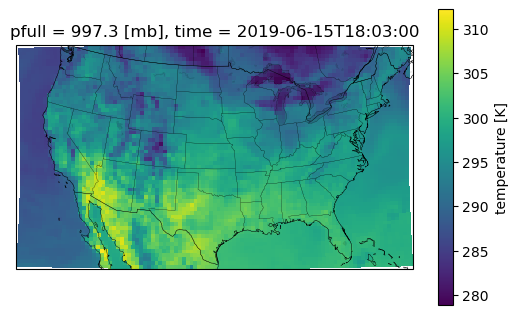

In [8]:
subplot_kws = {
    "projection": cartopy.crs.LambertConformal(central_longitude=-97.6, central_latitude=35.4)
}
plt.clf()
pcm = ds.tmp.isel(time=0, pfull=-1).plot.pcolormesh(
    x="lont",
    y="latt",
    transform=cartopy.crs.PlateCarree(),
    cbar_kwargs={"shrink": 0.8},
    subplot_kws=subplot_kws,
)
physics_tend.add_conus_features(pcm.axes)
plt.show()

2025-03-05 16:12:12,491 - INFO - <xarray.Dataset> Size: 40B
Dimensions:             ()
Data variables:
    dtend_temp_lw       float32 4B <Quantity(0.0007711350917816162, 'kelvin /...
    dtend_temp_sw       float32 4B <Quantity(0.000986331608146429, 'kelvin / ...
    dtend_temp_pbl      float32 4B <Quantity(0.023379534482955933, 'kelvin / ...
    dtend_temp_deepcnv  float32 4B <Quantity(0.0023415246978402138, 'kelvin /...
    dtend_temp_shalcnv  float32 4B <Quantity(0.0017130787018686533, 'kelvin /...
    dtend_temp_mp       float32 4B <Quantity(0.012622805312275887, 'kelvin / ...
    dtend_temp_orogwd   float32 4B <Quantity(0.0, 'kelvin / second')>
    dtend_temp_cnvgwd   float32 4B <Quantity(0.0, 'kelvin / second')>
    dtend_temp_phys     float32 4B <Quantity(0.02394735813140869, 'kelvin / s...
    dtend_temp_nophys   float32 4B <Quantity(0.00692799873650074, 'kelvin / s...
2025-03-05 16:12:12,493 - WARNING - assume tendencies_were_zeroed_and_averaged_after_every_output
2025-03-05 

['temperature tendency due to long wave radiation', 'temperature tendency due to short wave radiation', 'temperature tendency due to PBL', 'temperature tendency due to deep convection', 'temperature tendency due to shallow convection', 'temperature tendency due to microphysics', 'temperature tendency due to orographic gravity wave drag', 'temperature tendency due to convective gravity wave drag', 'temperature tendency due to physics', 'temperature tendency due to non-physics processes']


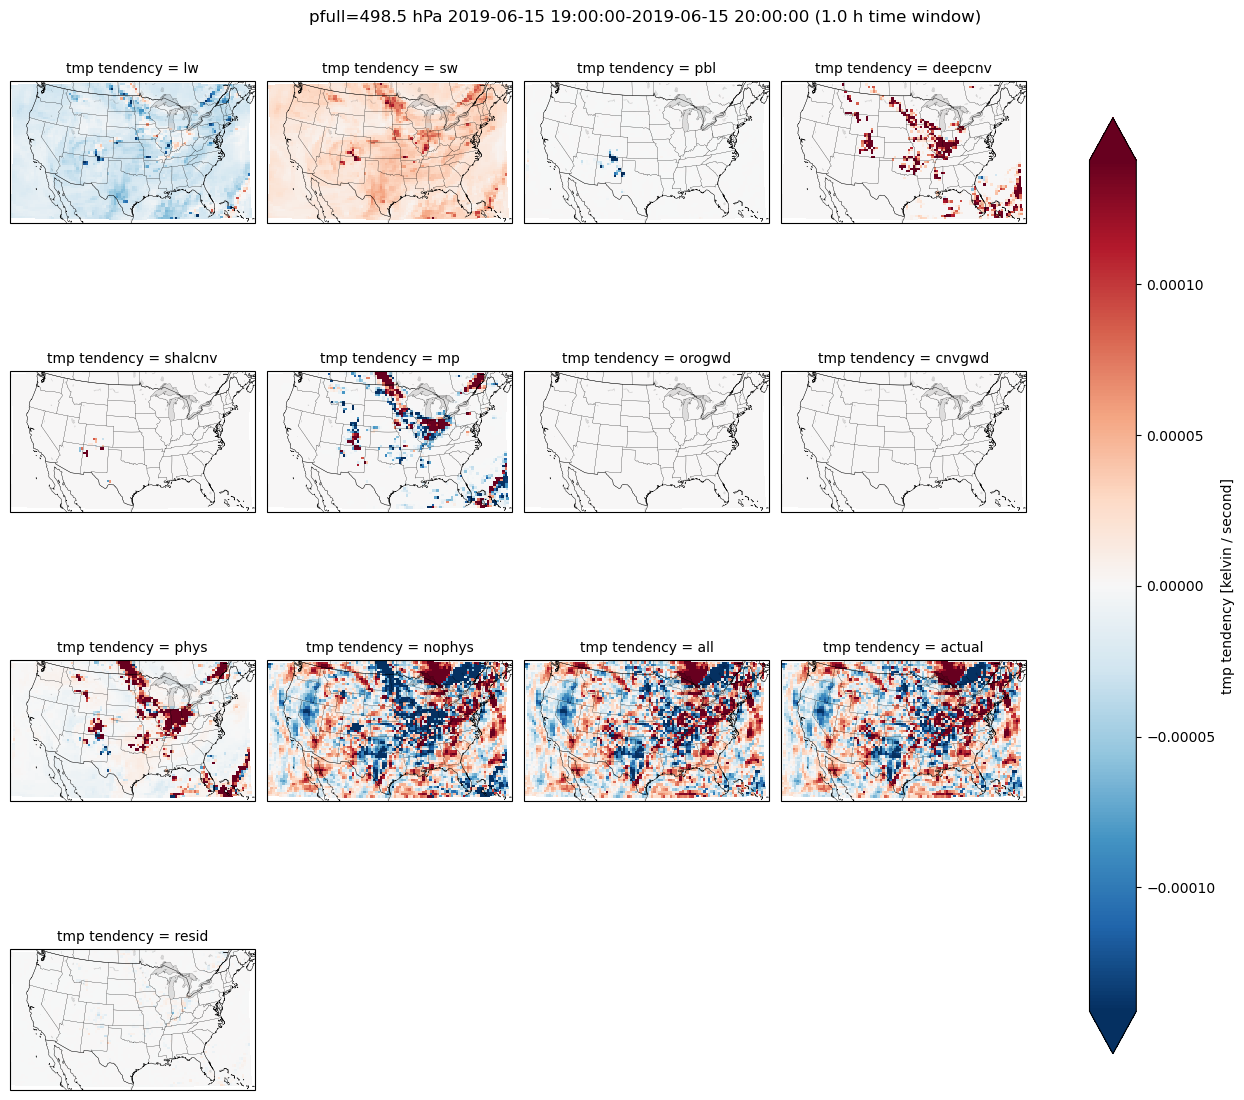

In [9]:
pcm = planview_fv3.planview(
    config,
    ds,
    pfull=[500],
    robust=True,
    shp=None,
    twindow=1,
    validtime="20190615T20",
)

2025-03-05 16:12:14,347 - INFO - <xarray.Dataset> Size: 40B
Dimensions:             ()
Data variables:
    dtend_temp_lw       float32 4B <Quantity(0.0007711350917816162, 'kelvin /...
    dtend_temp_sw       float32 4B <Quantity(0.000986331608146429, 'kelvin / ...
    dtend_temp_pbl      float32 4B <Quantity(0.023379534482955933, 'kelvin / ...
    dtend_temp_deepcnv  float32 4B <Quantity(0.0023415246978402138, 'kelvin /...
    dtend_temp_shalcnv  float32 4B <Quantity(0.0017130787018686533, 'kelvin /...
    dtend_temp_mp       float32 4B <Quantity(0.012622805312275887, 'kelvin / ...
    dtend_temp_orogwd   float32 4B <Quantity(0.0, 'kelvin / second')>
    dtend_temp_cnvgwd   float32 4B <Quantity(0.0, 'kelvin / second')>
    dtend_temp_phys     float32 4B <Quantity(0.02394735813140869, 'kelvin / s...
    dtend_temp_nophys   float32 4B <Quantity(0.00692799873650074, 'kelvin / s...
2025-03-05 16:12:14,348 - WARNING - assume tendencies_were_zeroed_and_averaged_after_every_output
2025-03-05 

['temperature tendency due to long wave radiation', 'temperature tendency due to short wave radiation', 'temperature tendency due to PBL', 'temperature tendency due to deep convection', 'temperature tendency due to shallow convection', 'temperature tendency due to microphysics', 'temperature tendency due to orographic gravity wave drag', 'temperature tendency due to convective gravity wave drag', 'temperature tendency due to physics', 'temperature tendency due to non-physics processes']


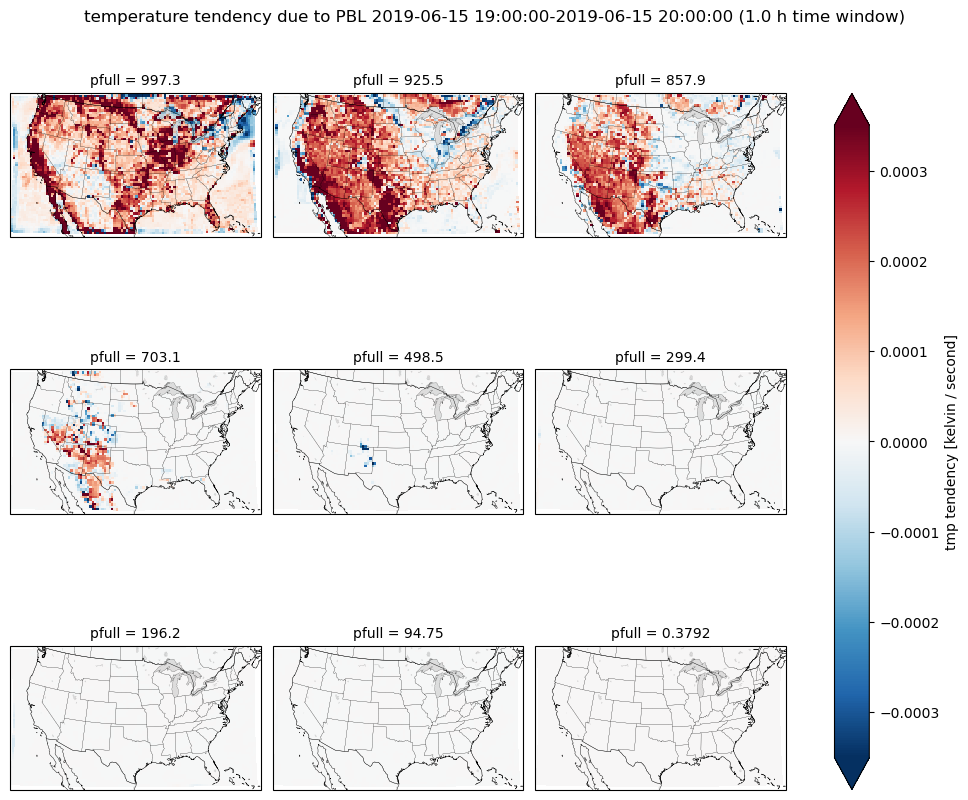

In [10]:
pcm = planview_fv3.planview(
    config,
    ds,
    pfull=[1000, 925, 850, 700, 500, 300, 200, 100, 0],
    robust=True,
    shp=None,
    twindow=1,
    validtime="20190615T20",
)

2025-03-05 16:12:15,609 - INFO - <xarray.Dataset> Size: 40B
Dimensions:             ()
Data variables:
    dtend_temp_lw       float32 4B <Quantity(0.0007711350917816162, 'kelvin /...
    dtend_temp_sw       float32 4B <Quantity(0.000986331608146429, 'kelvin / ...
    dtend_temp_pbl      float32 4B <Quantity(0.023379534482955933, 'kelvin / ...
    dtend_temp_deepcnv  float32 4B <Quantity(0.0023415246978402138, 'kelvin /...
    dtend_temp_shalcnv  float32 4B <Quantity(0.0017130787018686533, 'kelvin /...
    dtend_temp_mp       float32 4B <Quantity(0.012622805312275887, 'kelvin / ...
    dtend_temp_orogwd   float32 4B <Quantity(0.0, 'kelvin / second')>
    dtend_temp_cnvgwd   float32 4B <Quantity(0.0, 'kelvin / second')>
    dtend_temp_phys     float32 4B <Quantity(0.02394735813140869, 'kelvin / s...
    dtend_temp_nophys   float32 4B <Quantity(0.00692799873650074, 'kelvin / s...
2025-03-05 16:12:15,610 - WARNING - assume tendencies_were_zeroed_and_averaged_after_every_output
2025-03-05 

['temperature tendency due to long wave radiation', 'temperature tendency due to short wave radiation', 'temperature tendency due to PBL', 'temperature tendency due to deep convection', 'temperature tendency due to shallow convection', 'temperature tendency due to microphysics', 'temperature tendency due to orographic gravity wave drag', 'temperature tendency due to convective gravity wave drag', 'temperature tendency due to physics', 'temperature tendency due to non-physics processes']


2025-03-05 16:12:15,872 - INFO - plot area-weighted spatial average...


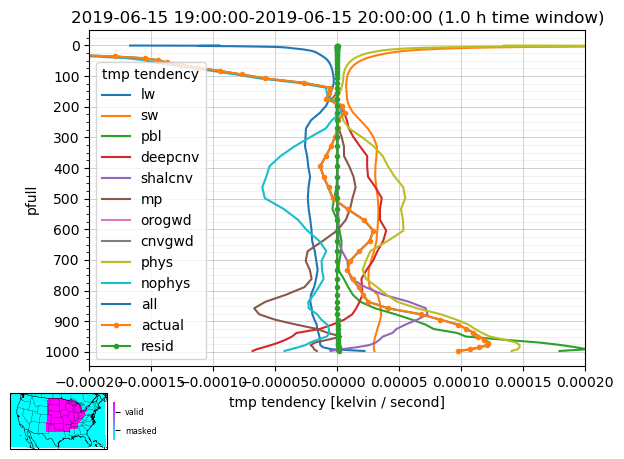

In [11]:
pcm = vert_profile_fv3.vert_profile(
    config,
    ds,
    shp="shapefiles/MID_CONUS",
    twindow=1,
    xmin=-0.0002,
    xmax=0.0002,
    ofile=METPLOTPY_BASE / "docs/Users_Guide/figure/tmp.vert_profile.MID_CONUS.png",
)

2025-03-05 16:12:17,377 - INFO - <xarray.Dataset> Size: 40B
Dimensions:             ()
Data variables:
    dtend_temp_lw       float32 4B <Quantity(0.0007711350917816162, 'kelvin /...
    dtend_temp_sw       float32 4B <Quantity(0.000986331608146429, 'kelvin / ...
    dtend_temp_pbl      float32 4B <Quantity(0.023379534482955933, 'kelvin / ...
    dtend_temp_deepcnv  float32 4B <Quantity(0.0023415246978402138, 'kelvin /...
    dtend_temp_shalcnv  float32 4B <Quantity(0.0017130787018686533, 'kelvin /...
    dtend_temp_mp       float32 4B <Quantity(0.012622805312275887, 'kelvin / ...
    dtend_temp_orogwd   float32 4B <Quantity(0.0, 'kelvin / second')>
    dtend_temp_cnvgwd   float32 4B <Quantity(0.0, 'kelvin / second')>
    dtend_temp_phys     float32 4B <Quantity(0.02394735813140869, 'kelvin / s...
    dtend_temp_nophys   float32 4B <Quantity(0.00692799873650074, 'kelvin / s...
2025-03-05 16:12:17,379 - WARNING - assume tendencies_were_zeroed_and_averaged_after_every_output
2025-03-05 

['temperature tendency due to long wave radiation', 'temperature tendency due to short wave radiation', 'temperature tendency due to PBL', 'temperature tendency due to deep convection', 'temperature tendency due to shallow convection', 'temperature tendency due to microphysics', 'temperature tendency due to orographic gravity wave drag', 'temperature tendency due to convective gravity wave drag', 'temperature tendency due to physics', 'temperature tendency due to non-physics processes']


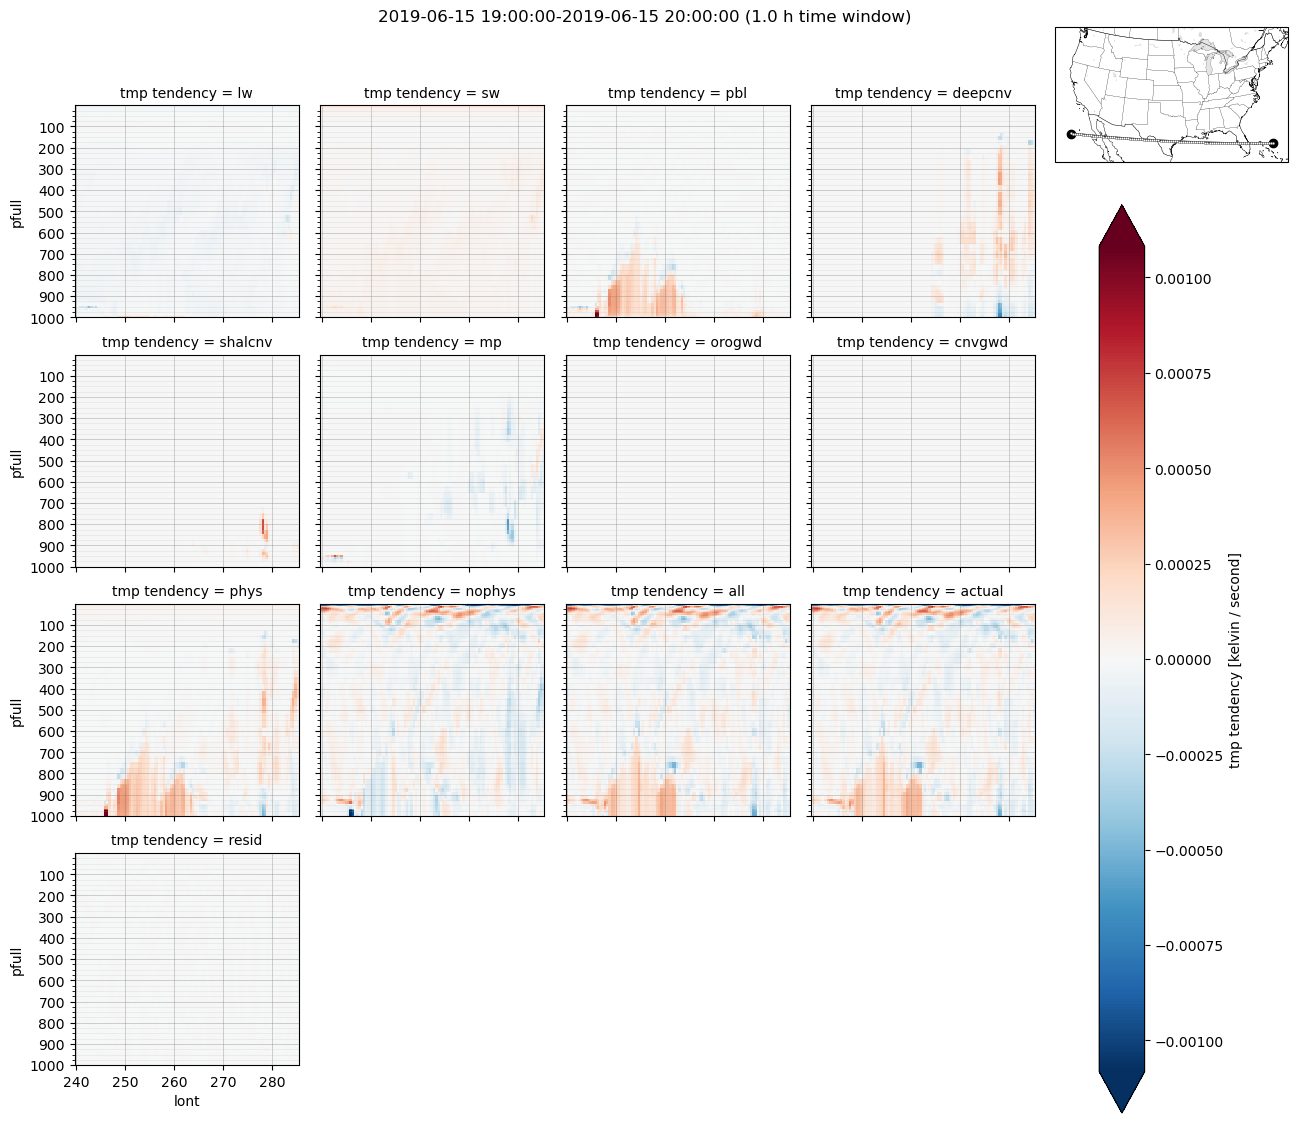

In [12]:
pcm = cross_section_vert.cross_section_vert(
    config,
    ds,
    statevarname="tmp",
    twindow=1,
    # crs={"grid_mapping_name": "stereographic", "central_longitude": -100},
)

In [13]:
# Cutoff lows and May's UFS


# stitch tile3 (north pole) above tile5 (Americas)
def stitch_tiles(t3, t5):
    # add size of grid_yt dimension to coordinate values of t5 grid_yt.
    t5 = t5.assign_coords(grid_yt=t5.grid_yt + t5.grid_yt.size)
    # Ensure "filename" is removed from all levels of attributes
    for ds in [t3, t5]:
        ds.attrs.pop("filename", None)  # Remove from dataset attributes
        for var in ds.variables:
            ds[var].attrs.pop("filename", None)  # Remove from variable attributes
    c = xarray.concat([t3, t5], dim="grid_yt", combine_attrs="no_conflicts")
    return c


config = yaml.load(
    open(
        PHYSICS_TEND_DIR / "UFS.yaml",
        encoding="utf8",
    ),
    Loader=yaml.FullLoader,
)
CAMPAIGN = Path("/glade/campaign/mmm/parc/mwong/ufs-mrw")
grid_spec3 = xarray.open_dataset(CAMPAIGN / f"grid/grid_spec.tile3.nc")
grid_spec5 = xarray.open_dataset(CAMPAIGN / f"grid/grid_spec.tile5.nc")

gds = stitch_tiles(grid_spec3, grid_spec5)

lont = gds[config["lon_name"]]
latt = gds[config["lat_name"]]
t3 = physics_tend.get_fv3ds(
    config,
    CAMPAIGN / f"2020040512.F240.C768/fv3_history2d.tile3.nc",
)
t5 = physics_tend.get_fv3ds(
    config,
    CAMPAIGN / f"2020040512.F240.C768/fv3_history2d.tile5.nc",
)
print("stitch history")
ds = stitch_tiles(t3, t5)

ds = ds.assign_coords(lont=lont, latt=latt)
config

2025-03-05 16:12:24,254 - INFO - Opening /glade/campaign/mmm/parc/mwong/ufs-mrw/2020040512.F240.C768/fv3_history2d.tile3.nc
2025-03-05 16:12:25,481 - INFO - dq3dt_deepcnv
2025-03-05 16:12:25,514 - INFO - dq3dt_mp
2025-03-05 16:12:25,545 - INFO - dq3dt_nonphys
2025-03-05 16:12:25,576 - INFO - dq3dt_pbl
2025-03-05 16:12:25,609 - INFO - dq3dt_shalcnv
2025-03-05 16:12:25,628 - INFO - q
2025-03-05 16:12:25,658 - INFO - dt3dt_deepcnv
2025-03-05 16:12:25,688 - INFO - dt3dt_mp
2025-03-05 16:12:25,956 - INFO - dt3dt_nonphys
2025-03-05 16:12:25,989 - INFO - dt3dt_pbl
2025-03-05 16:12:26,019 - INFO - dt3dt_shalcnv
2025-03-05 16:12:26,048 - INFO - dt3dt_cnvgwd
2025-03-05 16:12:26,097 - INFO - dt3dt_lw
2025-03-05 16:12:26,143 - INFO - dt3dt_sw
2025-03-05 16:12:26,171 - INFO - dt3dt_rdamp
2025-03-05 16:12:26,199 - INFO - dt3dt_ogwd
2025-03-05 16:12:26,215 - INFO - t
2025-03-05 16:12:26,242 - INFO - du3dt_deepcnv
2025-03-05 16:12:26,271 - INFO - du3dt_cnvgwd
2025-03-05 16:12:26,298 - INFO - du3dt_mp


stitch history


{'tendency_varnames': {'q': ['dq3dt_deepcnv',
   'dq3dt_mp',
   'dq3dt_nonphys',
   'dq3dt_pbl',
   'dq3dt_shalcnv'],
  't': ['dt3dt_deepcnv',
   'dt3dt_mp',
   'dt3dt_nonphys',
   'dt3dt_pbl',
   'dt3dt_shalcnv',
   'dt3dt_cnvgwd',
   'dt3dt_lw',
   'dt3dt_sw',
   'dt3dt_rdamp',
   'dt3dt_ogwd'],
  'u': ['du3dt_deepcnv',
   'du3dt_cnvgwd',
   'du3dt_mp',
   'du3dt_nonphys',
   'du3dt_ogwd',
   'du3dt_pbl',
   'du3dt_rdamp',
   'du3dt_shalcnv'],
  'v': ['dv3dt_deepcnv',
   'dv3dt_cnvgwd',
   'dv3dt_mp',
   'dv3dt_nonphys',
   'dv3dt_ogwd',
   'dv3dt_pbl',
   'dv3dt_rdamp',
   'dv3dt_shalcnv']},
 'lon_name': 'grid_lont',
 'lat_name': 'grid_latt',
 'extent': [-122, -72.7, 22.1, 49.5],
 'standard_parallel': 38.139,
 'cmap': 'RdBu_r',
 'crs': None,
 'debug': False,
 'dpi': 100,
 'ncols': None,
 'fineprint': False,
 'pfull': [1000, 925, 850, 700, 500, 300, 200, 100, 0],
 'resid': True,
 'robust': True,
 'sel_method': 'nearest',
 'shp': None,
 'startpt': [28, -120],
 'endpt': [26, -75],
 'st

In [22]:
# for small UFS test case, there are no q or v.
if "q" in config["tendency_varnames"]:
    del config["tendency_varnames"]["q"]
if "v" in config["tendency_varnames"]:
    del config["tendency_varnames"]["v"]
t5 = physics_tend.get_fv3ds(
    config,
    TEST_FILE_DIR
    / f"model_applications/miscellaneous/fv3_physics_tendency/fv3_history2d.tile5.nc_small",
)
grid_spec5 = xarray.open_dataset(
    TEST_FILE_DIR
    / f"model_applications/miscellaneous/fv3_physics_tendency/grid_spec.tile5.nc_small"
)

2025-03-05 16:18:15,837 - INFO - Opening /glade/campaign/mmm/parc/ahijevyc/METplotpy/model_applications/miscellaneous/fv3_physics_tendency/fv3_history2d.tile5.nc_small
2025-03-05 16:18:16,139 - INFO - dt3dt_deepcnv
2025-03-05 16:18:16,166 - INFO - dt3dt_mp
2025-03-05 16:18:16,191 - INFO - dt3dt_nonphys
2025-03-05 16:18:16,217 - INFO - dt3dt_pbl
2025-03-05 16:18:16,241 - INFO - dt3dt_shalcnv
2025-03-05 16:18:16,265 - INFO - dt3dt_cnvgwd
2025-03-05 16:18:16,290 - INFO - dt3dt_lw
2025-03-05 16:18:16,312 - INFO - dt3dt_sw
2025-03-05 16:18:16,335 - INFO - dt3dt_rdamp
2025-03-05 16:18:16,356 - INFO - dt3dt_ogwd
2025-03-05 16:18:16,393 - INFO - t
2025-03-05 16:18:16,420 - INFO - du3dt_deepcnv
2025-03-05 16:18:16,443 - INFO - du3dt_cnvgwd
2025-03-05 16:18:16,467 - INFO - du3dt_mp
2025-03-05 16:18:16,489 - INFO - du3dt_nonphys
2025-03-05 16:18:16,965 - INFO - du3dt_ogwd
2025-03-05 16:18:16,986 - INFO - du3dt_pbl
2025-03-05 16:18:17,006 - INFO - du3dt_rdamp
2025-03-05 16:18:17,026 - INFO - du3dt

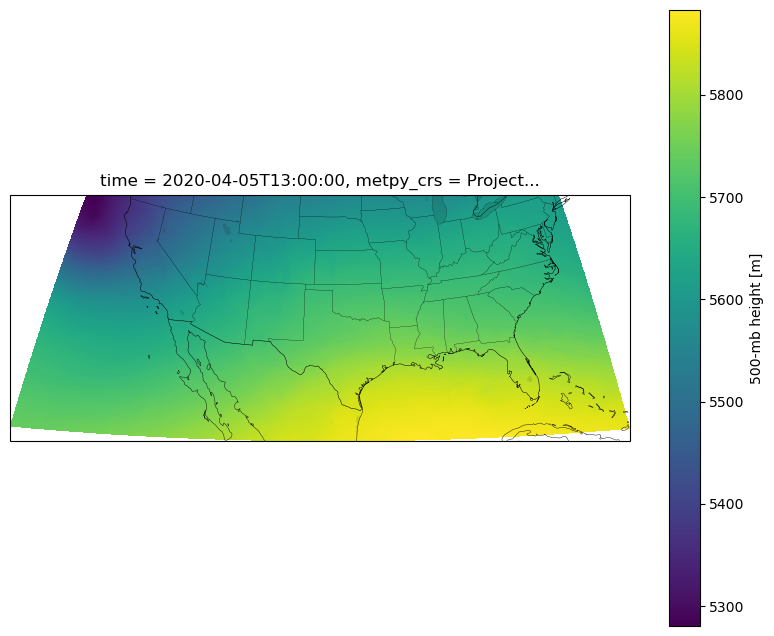

2025-03-04 17:39:14,991 - distributed.worker - ERROR - Failed to communicate with scheduler during heartbeat.
Traceback (most recent call last):
  File "/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/comm/tcp.py", line 226, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/worker.py", line 1269, in heartbeat
    response = await retry_operation(
               ^^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
    )
    ^
  File "/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/utils_comm.py", line 416, in retry_operation
    return await retry(
           ^^^^^^^^^^^^
    ...<5 lines>...
 

In [46]:
pcm = (
    t5.assign_coords(lont=grid_spec5[config["lon_name"]], latt=grid_spec5[config["lat_name"]])
    .sel(grid_xt=slice(None, 200), grid_yt=slice(150,600))
    .z500
    .isel(time=0)
    .metpy.assign_crs(
        grid_mapping_name="stereographic",
        central_longitude=-100,
        central_latitude=0,
    )
    .plot.pcolormesh(
        x="lont",
        y="latt",
        transform=cartopy.crs.PlateCarree(),
        cbar_kwargs={"shrink": 0.8},
        subplot_kws=subplot_kws,
        figsize=(10, 10),
    )
)
physics_tend.add_conus_features(pcm.axes)
plt.show()

<Figure size 640x480 with 0 Axes>

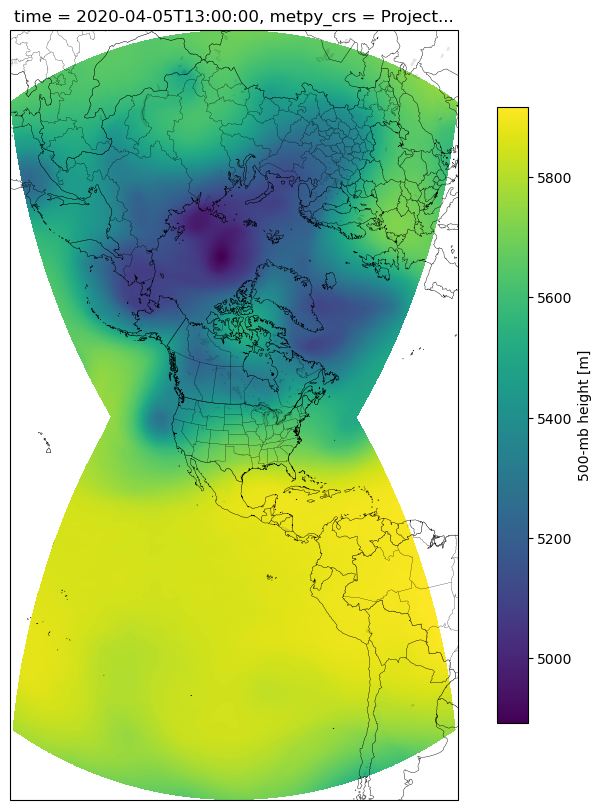

In [15]:
subplot_kws = {
    "projection": cartopy.crs.Stereographic(
        central_longitude=-100,
        central_latitude=45,
    )
}
plt.clf()

da = (
    ds.z500.drop_vars(["grid_yt", "grid_xt"])
    .rename({"grid_yt": "y", "grid_xt": "x"})
    .isel(time=0)
    .metpy.assign_crs(
        grid_mapping_name="stereographic",
        central_longitude=-100,
        central_latitude=45,
    )
    # .metpy.assign_y_x(force=True, tolerance=5e7 * units.m)
)

pcm = da.plot.pcolormesh(
    x="lont",
    y="latt",
    transform=cartopy.crs.PlateCarree(),
    cbar_kwargs={"shrink": 0.8},
    subplot_kws=subplot_kws,
    figsize=(10, 10),
)
physics_tend.add_conus_features(pcm.axes)
plt.show()

In [16]:
ds

<xarray.Dataset> Size: 264GB
Dimensions:        (time: 240, grid_yt: 1536, grid_xt: 768, pfull: 12)
Coordinates:
  * grid_xt        (grid_xt) float32 3kB 1.0 2.0 3.0 4.0 ... 766.0 767.0 768.0
  * grid_yt        (grid_yt) float32 6kB 1.0 2.0 3.0 ... 1.535e+03 1.536e+03
  * time           (time) datetime64[ns] 2kB 2020-04-05T13:00:00 ... 2020-04-...
  * pfull          (pfull) int64 96B 1000 925 850 700 600 ... 250 200 150 100
    lont           (grid_yt, grid_xt) float32 5MB 35.0 35.1 35.2 ... 305.0 305.0
    latt           (grid_yt, grid_xt) float32 5MB 35.31 35.36 ... -35.15 -35.24
Data variables: (12/219)
    us             (time, grid_yt, grid_xt) float32 1GB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    vs             (time, grid_yt, grid_xt) float32 1GB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    z1000          (time, grid_yt, grid_xt) float32 1GB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    z925           (time, grid_yt, grid_xt) float32 1GB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    z850           (time, grid_yt, grid_xt) float32 1GB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    z700           (time, grid_yt, grid_xt) float32 1GB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    ...             ...
    dv3dt_nonphys  (pfull, grid_yt, grid_xt) float32 57MB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    dv3dt_ogwd     (pfull, grid_yt, grid_xt) float32 57MB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    dv3dt_pbl      (pfull, grid_yt, grid_xt) float32 57MB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    dv3dt_rdamp    (pfull, grid_yt, grid_xt) float32 57MB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    dv3dt_shalcnv  (pfull, grid_yt, grid_xt) float32 57MB dask.array<chunksize=(1, 768, 768), meta=np.ndarray>
    v              (pfull, time, grid_yt, grid_xt) float32 14GB dask.array<chunksize=(1, 1, 768, 768), meta=np.ndarray>
Attributes: (12/30)
    title:                                                   20200405.12Z.C76...
    grid_type:                                               regular
    grid_tile:                                               N/A
    tendency_varnames:                                       {'q': ['dq3dt_de...
    lon_name:                                                grid_lont
    lat_name:                                                grid_latt
    ...                                                      ...
    twindow:                                                 6
    validtime:                                               20200409T12
    vmin:                                                    None
    vmax:                                                    None
    xmin:                                                    -0.0005
    xmax:                                                    0.0004

2025-03-04 10:05:58,660 - INFO - <xarray.Dataset> Size: 32B
Dimensions:        ()
Data variables:
    du3dt_deepcnv  float32 4B <Quantity(0.007855118252336979, 'meter / second...
    du3dt_cnvgwd   float32 4B <Quantity(9.29196467041038e-05, 'meter / second...
    du3dt_mp       float32 4B <Quantity(0.00018083277973346412, 'meter / seco...
    du3dt_nonphys  float32 4B <Quantity(0.020676003769040108, 'meter / second...
    du3dt_ogwd     float32 4B <Quantity(0.022290078923106194, 'meter / second...
    du3dt_pbl      float32 4B <Quantity(0.018830137327313423, 'meter / second...
    du3dt_rdamp    float32 4B <Quantity(0.0, 'meter / second ** 2')>
    du3dt_shalcnv  float32 4B <Quantity(0.0, 'meter / second ** 2')>
2025-03-04 10:05:58,818 - INFO - calculate actual change in u
2025-03-04 10:05:58,821 - INFO - from 2020-04-09 06:00:00 to 2020-04-09 12:00:00


['du3dt_deepcnv', 'du3dt_cnvgwd', 'du3dt_mp', 'du3dt_nonphys', 'du3dt_ogwd', 'du3dt_pbl', 'du3dt_rdamp', 'du3dt_shalcnv']


2025-03-04 10:05:59,408 - INFO - subtract actual tendency from all_tendencies to get residual
/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 540.03 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


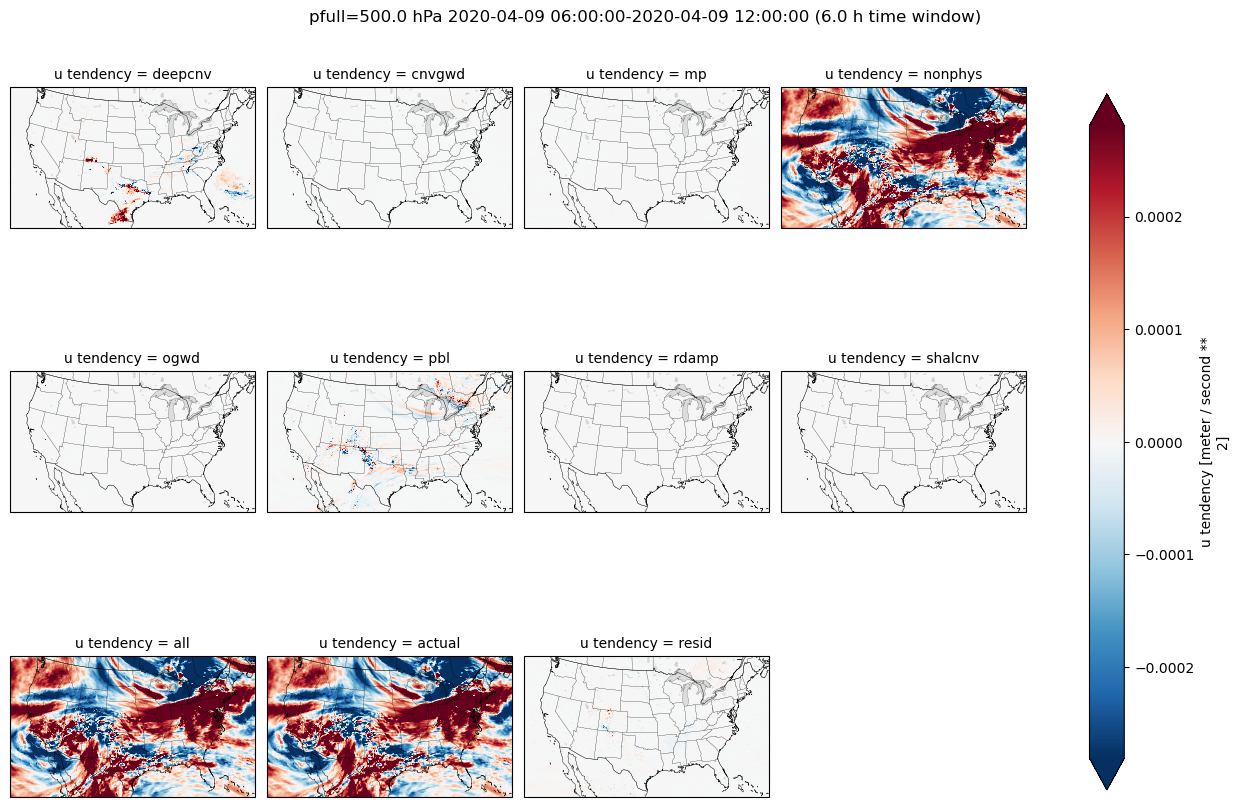

In [17]:
pcm = planview_fv3.planview(
    config,
    ds,
    pfull=[500],
    robust=True,
    shp=None,
    statevarname="u",
)

2025-03-04 10:06:43,167 - INFO - <xarray.Dataset> Size: 32B
Dimensions:        ()
Data variables:
    du3dt_deepcnv  float32 4B <Quantity(0.007855118252336979, 'meter / second...
    du3dt_cnvgwd   float32 4B <Quantity(9.29196467041038e-05, 'meter / second...
    du3dt_mp       float32 4B <Quantity(0.00018083277973346412, 'meter / seco...
    du3dt_nonphys  float32 4B <Quantity(0.020676003769040108, 'meter / second...
    du3dt_ogwd     float32 4B <Quantity(0.022290078923106194, 'meter / second...
    du3dt_pbl      float32 4B <Quantity(0.018830137327313423, 'meter / second...
    du3dt_rdamp    float32 4B <Quantity(0.0, 'meter / second ** 2')>
    du3dt_shalcnv  float32 4B <Quantity(0.0, 'meter / second ** 2')>
2025-03-04 10:06:43,329 - INFO - calculate actual change in u
2025-03-04 10:06:43,333 - INFO - from 2020-04-09 06:00:00 to 2020-04-09 12:00:00


['du3dt_deepcnv', 'du3dt_cnvgwd', 'du3dt_mp', 'du3dt_nonphys', 'du3dt_ogwd', 'du3dt_pbl', 'du3dt_rdamp', 'du3dt_shalcnv']


2025-03-04 10:06:43,930 - INFO - subtract actual tendency from all_tendencies to get residual
2025-03-04 10:06:44,951 - INFO - Define cross section.
/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 540.71 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 432.17 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more informa

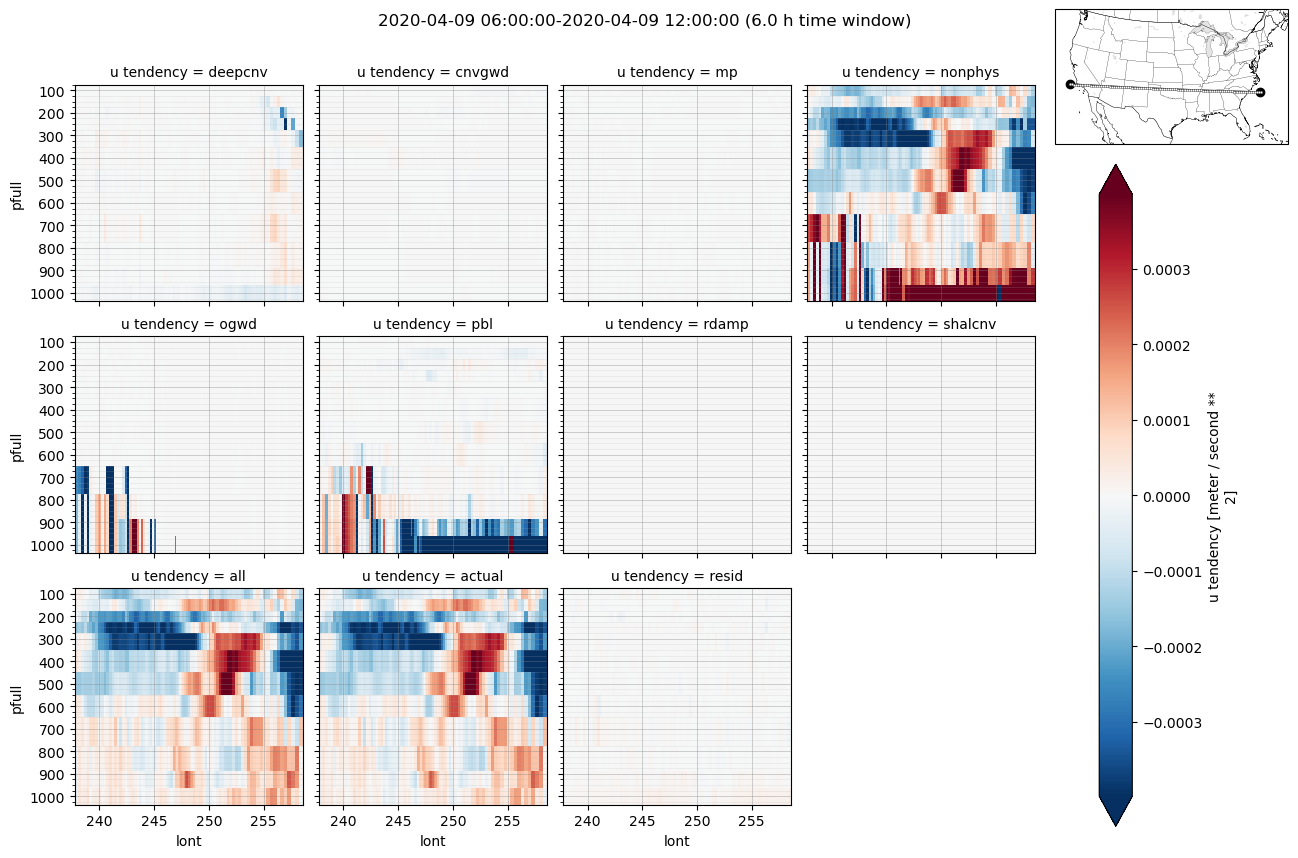

In [18]:
pcm = cross_section_vert.cross_section_vert(
    yaml.load(
        open(
            PHYSICS_TEND_DIR / "UFS.yaml",
            encoding="utf8",
        ),
        Loader=yaml.FullLoader,
    ),
    ds,
    robust=True,
    statevarname="u",
    startpt=[34, -122],
    endpt=[33, -76],
)

2025-03-03 10:01:35,135 - INFO - Opening /glade/campaign/mmm/parc/mwong/ufs-mrw/2020040812.F024.C768/fv3_history2d.tile3.nc
2025-03-03 10:01:36,279 - INFO - dq3dt_deepcnv
2025-03-03 10:01:36,309 - INFO - dq3dt_mp
2025-03-03 10:01:36,338 - INFO - dq3dt_nonphys
2025-03-03 10:01:36,369 - INFO - dq3dt_pbl
2025-03-03 10:01:36,399 - INFO - dq3dt_shalcnv
2025-03-03 10:01:36,414 - INFO - q
2025-03-03 10:01:36,443 - INFO - dt3dt_deepcnv
2025-03-03 10:01:36,470 - INFO - dt3dt_mp
2025-03-03 10:01:36,498 - INFO - dt3dt_nonphys
2025-03-03 10:01:36,527 - INFO - dt3dt_pbl
2025-03-03 10:01:36,553 - INFO - dt3dt_shalcnv
2025-03-03 10:01:36,579 - INFO - dt3dt_cnvgwd
2025-03-03 10:01:36,605 - INFO - dt3dt_lw
2025-03-03 10:01:36,630 - INFO - dt3dt_sw
2025-03-03 10:01:36,655 - INFO - dt3dt_rdamp
2025-03-03 10:01:36,680 - INFO - dt3dt_ogwd
2025-03-03 10:01:36,693 - INFO - t
2025-03-03 10:01:36,717 - INFO - du3dt_deepcnv
2025-03-03 10:01:36,742 - INFO - du3dt_cnvgwd
2025-03-03 10:01:36,767 - INFO - du3dt_mp


['du3dt_deepcnv', 'du3dt_cnvgwd', 'du3dt_mp', 'du3dt_nonphys', 'du3dt_ogwd', 'du3dt_pbl', 'du3dt_rdamp', 'du3dt_shalcnv']


2025-03-03 10:01:48,091 - INFO - subtract actual tendency from all_tendencies to get residual
/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 540.03 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


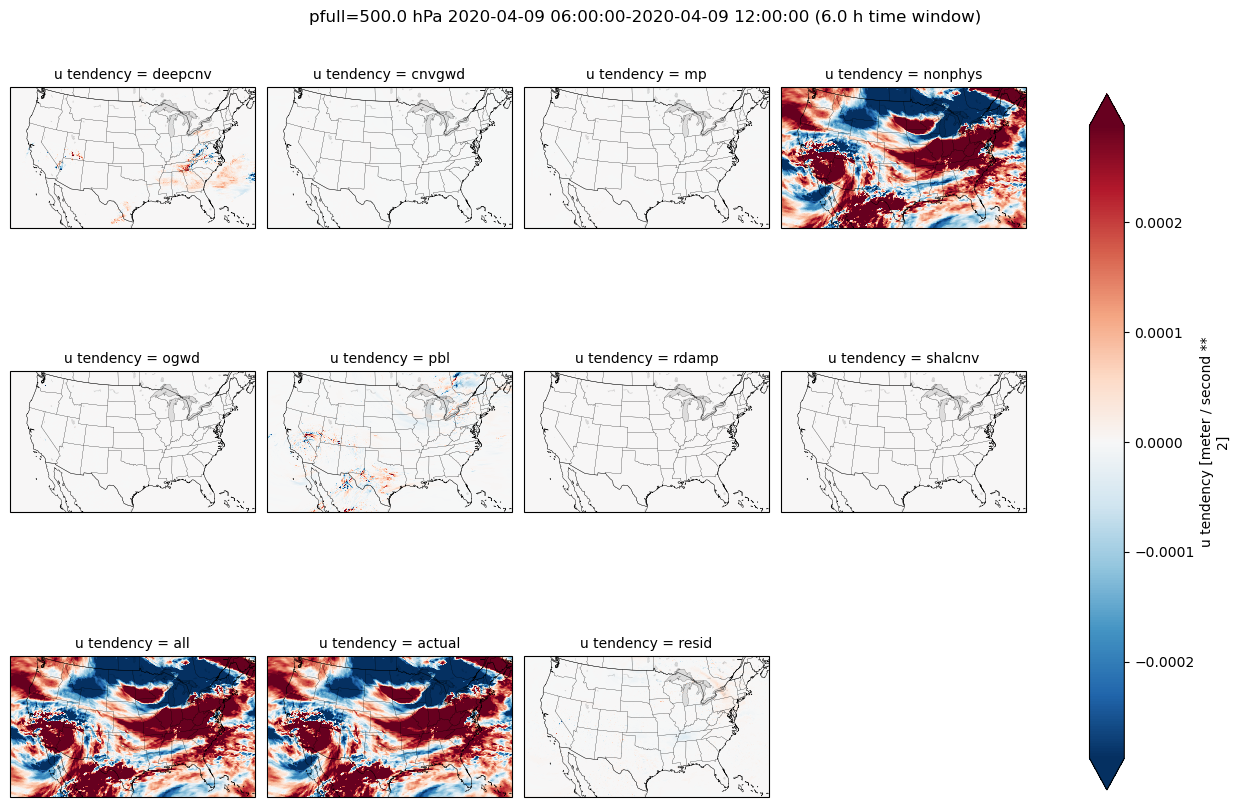

In [18]:
# another pair of forecast tiles
# This time with only 24-hours lead time
t3 = physics_tend.get_fv3ds(
    config,
    CAMPAIGN / f"2020040812.F024.C768/fv3_history2d.tile3.nc",
)
t5 = physics_tend.get_fv3ds(
    config,
    CAMPAIGN / f"2020040812.F024.C768/fv3_history2d.tile5.nc",
)
logging.info("stitch history")
ds2 = stitch_tiles(t3, t5)
ds2 = ds2.assign_coords(lont=lont, latt=latt)

pcm = planview_fv3.planview(
    config,
    ds2,
    pfull=[500],
    robust=True,
    shp=None,
    validtime=None,
)

2025-03-03 10:02:46,523 - INFO - validtime not configured. Using last time in history 2020-04-09T12:00:00.000000000.
2025-03-03 10:02:46,616 - INFO - <xarray.Dataset> Size: 32B
Dimensions:        ()
Data variables:
    du3dt_deepcnv  float32 4B <Quantity(0.005632380954921246, 'meter / second...
    du3dt_cnvgwd   float32 4B <Quantity(0.00011347390682203695, 'meter / seco...
    du3dt_mp       float32 4B <Quantity(0.0001666500320425257, 'meter / secon...
    du3dt_nonphys  float32 4B <Quantity(0.023765943944454193, 'meter / second...
    du3dt_ogwd     float32 4B <Quantity(0.01547930110245943, 'meter / second ...
    du3dt_pbl      float32 4B <Quantity(0.01889219880104065, 'meter / second ...
    du3dt_rdamp    float32 4B <Quantity(0.0, 'meter / second ** 2')>
    du3dt_shalcnv  float32 4B <Quantity(0.0, 'meter / second ** 2')>
2025-03-03 10:02:46,772 - INFO - calculate actual change in u
2025-03-03 10:02:46,775 - INFO - from 2020-04-09 06:00:00 to 2020-04-09 12:00:00


['du3dt_deepcnv', 'du3dt_cnvgwd', 'du3dt_mp', 'du3dt_nonphys', 'du3dt_ogwd', 'du3dt_pbl', 'du3dt_rdamp', 'du3dt_shalcnv']


2025-03-03 10:02:47,348 - INFO - subtract actual tendency from all_tendencies to get residual
/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 540.04 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Text(0.5, 0.98, '20200408.12Z.C768.32bit.non-hydro-20200405.12Z.C768.32bit.non-hydro\npfull=500.0 hPa 2020-04-09 06:00:00-2020-04-09 12:00:00 (6.0 h time window)')

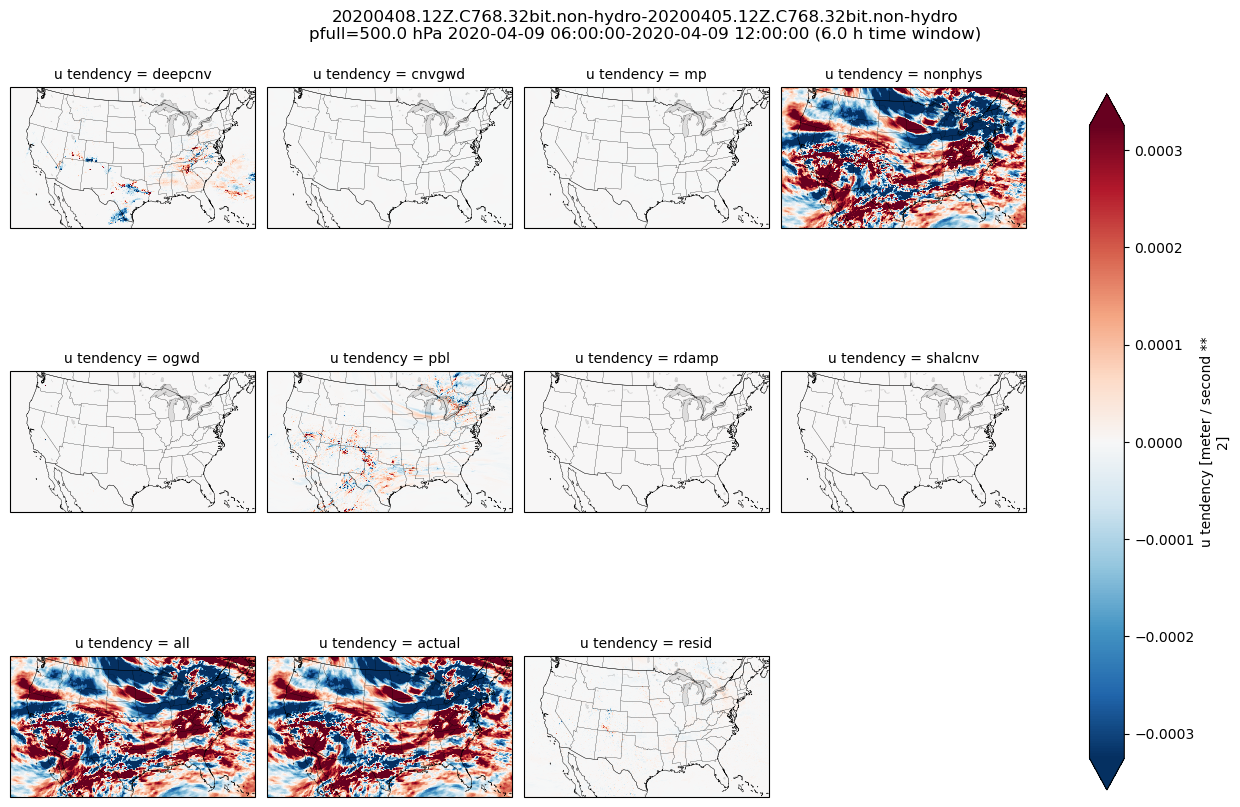

In [19]:
diff = ds2 - ds
# restore long_name attribute after subtraction
for da in diff:
    diff[da].attrs = ds[da].attrs
diff = diff.assign_coords(ds2.coords)
diff["area"] = gds["area"]

pcm = planview_fv3.planview(
    config,
    diff,
    pfull=[500],
    robust=True,
    shp=None,
    validtime=None,
)
pcm.fig.suptitle(f"{ds2.attrs['title']}-{ds.attrs['title']}\n{pcm.fig.get_suptitle()}")

2025-03-03 10:03:17,895 - INFO - validtime not configured. Using last time in history 2020-04-09T12:00:00.000000000.
2025-03-03 10:03:17,991 - INFO - <xarray.Dataset> Size: 32B
Dimensions:        ()
Data variables:
    du3dt_deepcnv  float32 4B <Quantity(0.005632380954921246, 'meter / second...
    du3dt_cnvgwd   float32 4B <Quantity(0.00011347390682203695, 'meter / seco...
    du3dt_mp       float32 4B <Quantity(0.0001666500320425257, 'meter / secon...
    du3dt_nonphys  float32 4B <Quantity(0.023765943944454193, 'meter / second...
    du3dt_ogwd     float32 4B <Quantity(0.01547930110245943, 'meter / second ...
    du3dt_pbl      float32 4B <Quantity(0.01889219880104065, 'meter / second ...
    du3dt_rdamp    float32 4B <Quantity(0.0, 'meter / second ** 2')>
    du3dt_shalcnv  float32 4B <Quantity(0.0, 'meter / second ** 2')>
2025-03-03 10:03:18,153 - INFO - calculate actual change in u
2025-03-03 10:03:18,157 - INFO - from 2020-04-09 06:00:00 to 2020-04-09 12:00:00


['du3dt_deepcnv', 'du3dt_cnvgwd', 'du3dt_mp', 'du3dt_nonphys', 'du3dt_ogwd', 'du3dt_pbl', 'du3dt_rdamp', 'du3dt_shalcnv']


2025-03-03 10:03:18,738 - INFO - subtract actual tendency from all_tendencies to get residual
2025-03-03 10:03:20,214 - INFO - area-weighted spatial average
2025-03-03 10:03:20,331 - INFO - plot area-weighted spatial average...
/glade/work/ahijevyc/conda-envs/metplotpy/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 546.36 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


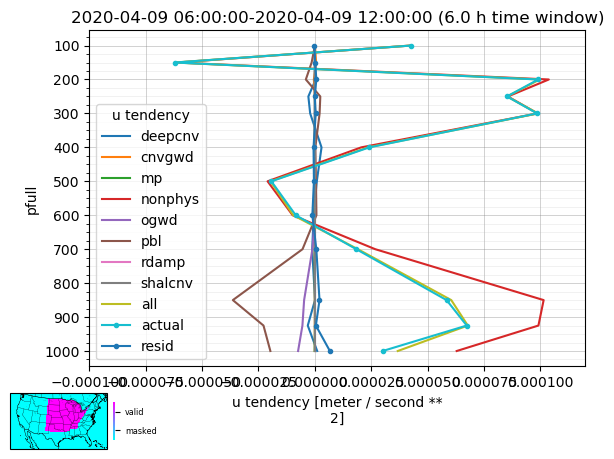

In [20]:
pcm = vert_profile_fv3.vert_profile(
    config, diff, shp="shapefiles/MID_CONUS", xmin=-1e-4, xmax=1.2e-4
)